In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv("data.csv")

In [56]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


The dataset contains measurements of cell nuclei. The diagnosis column is the target variable:

M = Malignant

B = Benign

In [57]:
df.shape

(569, 33)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [59]:
df.isnull().sum().sum()

np.int64(569)

In [60]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [61]:
# Remove unnecessary columns
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

In [62]:
# Convert diagnosis into numerical labels
df['diagnosis'] = df['diagnosis'].map({
    'B': 0,
    'M': 1
})

In [63]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Data Analysis (EDA)

1: Distribution of diagnoses

Understand how many benign and malignant cases are present.

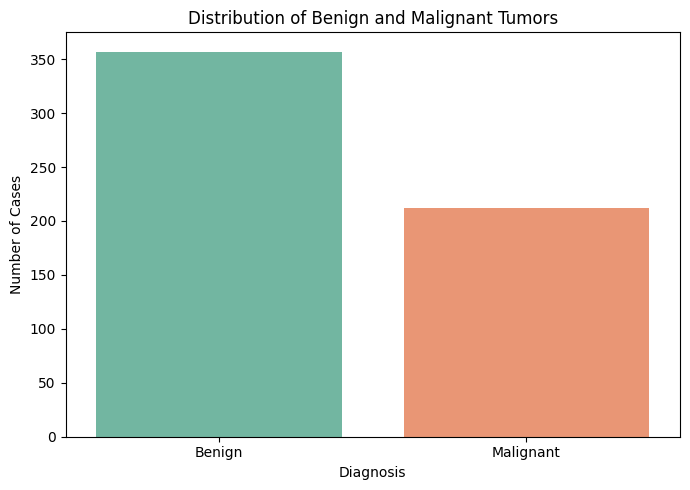

In [65]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='diagnosis',
    hue='diagnosis',
    palette='Set2',
    legend=False
)

plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.title('Distribution of Benign and Malignant Tumors')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.show()

2: Mean radius by diagnosis

Compare the distribution of mean radius for both classes.

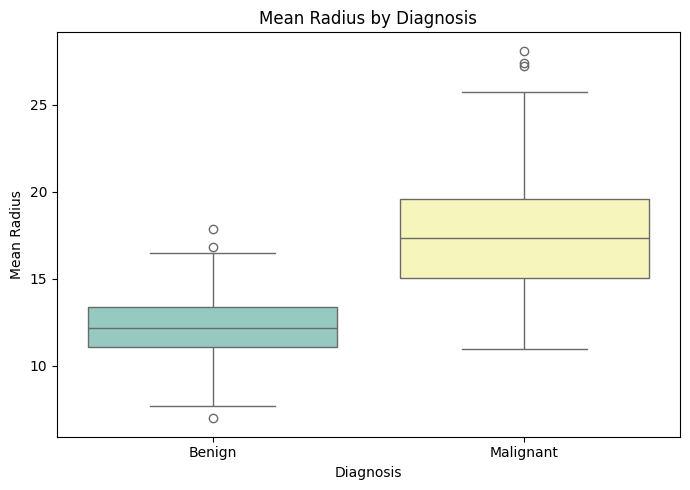

In [66]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='diagnosis',
    y='radius_mean',
    hue='diagnosis',
    palette='Set3',
    legend=False
)

plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.title('Mean Radius by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Mean Radius')
plt.tight_layout()
plt.show()

3: Correlation heatmap

Understand relationships between numerical features.

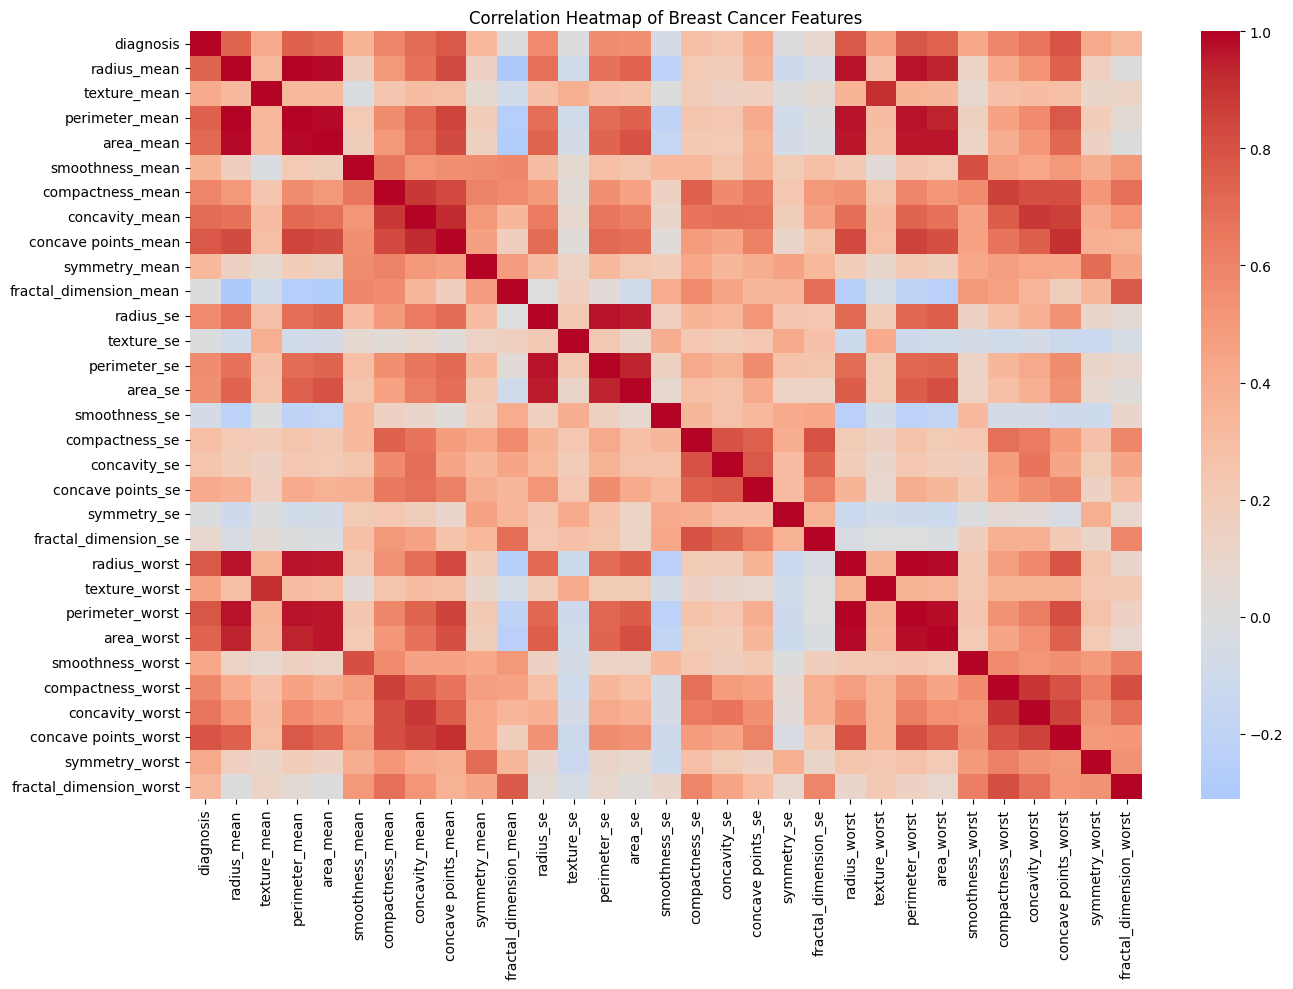

In [67]:
plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title('Correlation Heatmap of Breast Cancer Features')
plt.tight_layout()
plt.show()

4. Mean area by diagnosis

Compare the average tumor area between benign and malignant cases.

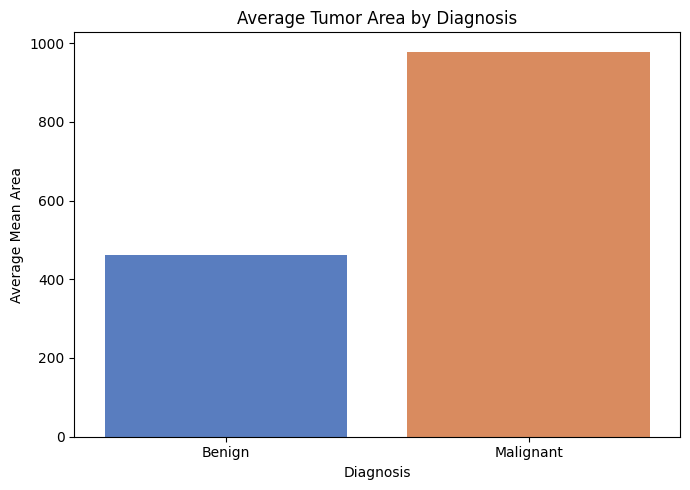

In [68]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x='diagnosis',
    y='area_mean',
    hue='diagnosis',
    palette='muted',
    legend=False,
    errorbar=None
)

plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.title('Average Tumor Area by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Average Mean Area')
plt.tight_layout()
plt.show()

### Feature selection

In [69]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

### Train/test split

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature scaling

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model 1 — Logistic Regression

In [74]:
from sklearn.linear_model import LogisticRegression

In [75]:
model1 = LogisticRegression(max_iter=5000)

model1.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [76]:
y_pred1 = model1.predict(X_test_scaled)

### Model 2 — Random Forest Classifier

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [79]:
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

Model Predictions

In [103]:
labels = {
    0: 'Benign',
    1: 'Malignant'
}

In [104]:
sample = X_test.iloc[:3]

sample_scaled = scaler.transform(sample)

In [105]:
predictions_lr = model1.predict(sample_scaled)
predictions_rf = model2.predict(sample)

In [106]:
prediction_results = pd.DataFrame({
    'Actual Diagnosis': [
        labels[value] for value in y_test.iloc[:3]
    ],
    'Logistic Regression': [
        labels[value] for value in predictions_lr
    ],
    'Random Forest': [
        labels[value] for value in predictions_rf
    ]
}, index=sample.index)

In [107]:
display(prediction_results)

,Actual Diagnosis,Logistic Regression,Random Forest
120,Benign,Benign,Benign
250,Malignant,Malignant,Malignant
375,Benign,Benign,Benign


### Model Evaluation

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [110]:
def evaluate_model(name, y_true, y_pred):

    print(name)

    print("Accuracy:",
          round(accuracy_score(y_true, y_pred), 4))

    print("Precision:",
          round(precision_score(y_true, y_pred, zero_division=0), 4))

    print("Recall:",
          round(recall_score(y_true, y_pred, zero_division=0), 4))

    print("F1-score:",
          round(f1_score(y_true, y_pred, zero_division=0), 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=['Benign', 'Malignant'],
        zero_division=0
    ))

    # Always create a 2 x 2 confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    print("Confusion Matrix:")
    print(cm)

    return cm

In [111]:
cm1 = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred1
)

Logistic Regression
Accuracy: 0.9649
Precision: 0.975
Recall: 0.9286
F1-score: 0.9512

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
[[71  1]
 [ 3 39]]


In [112]:
cm2 = evaluate_model(
    "Random Forest",
    y_test,
    y_pred2
)

Random Forest
Accuracy: 0.9737
Precision: 1.0
Recall: 0.9286
F1-score: 0.963

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
[[72  0]
 [ 3 39]]


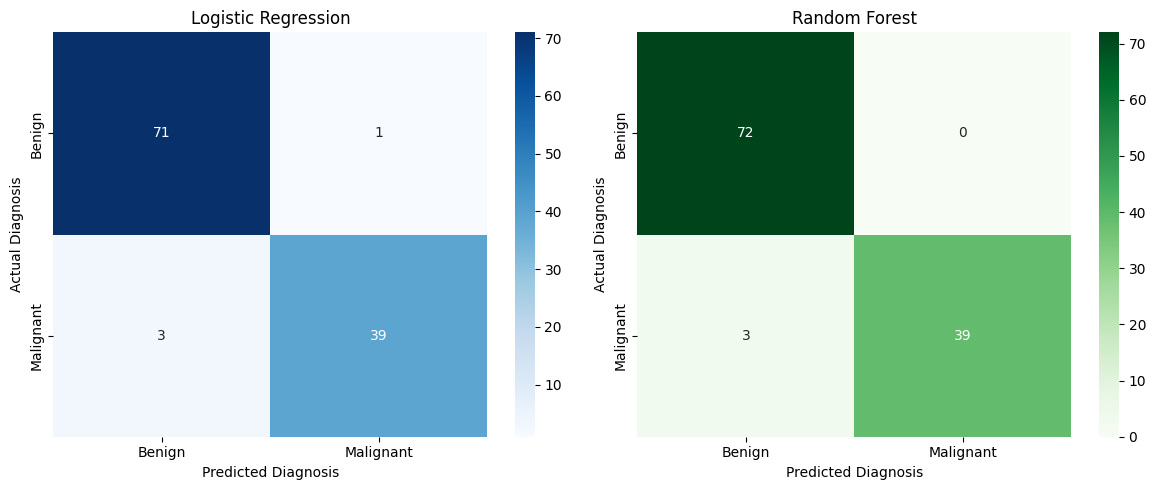

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant'],
    ax=axes[0]
)

axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Diagnosis')
axes[0].set_ylabel('Actual Diagnosis')

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant'],
    ax=axes[1]
)

axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted Diagnosis')
axes[1].set_ylabel('Actual Diagnosis')

plt.tight_layout()
plt.show()

### Model Comparison

In [117]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2)
    ],
    'Precision': [
        precision_score(y_test, y_pred1, zero_division=0),
        precision_score(y_test, y_pred2, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred1, zero_division=0),
        recall_score(y_test, y_pred2, zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, y_pred1, zero_division=0),
        f1_score(y_test, y_pred2, zero_division=0)
    ]
})

print("Model Comparison:")
display(results.round(4))

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9649,0.975,0.9286,0.9512
1,Random Forest,0.9737,1.000,0.9286,0.9630


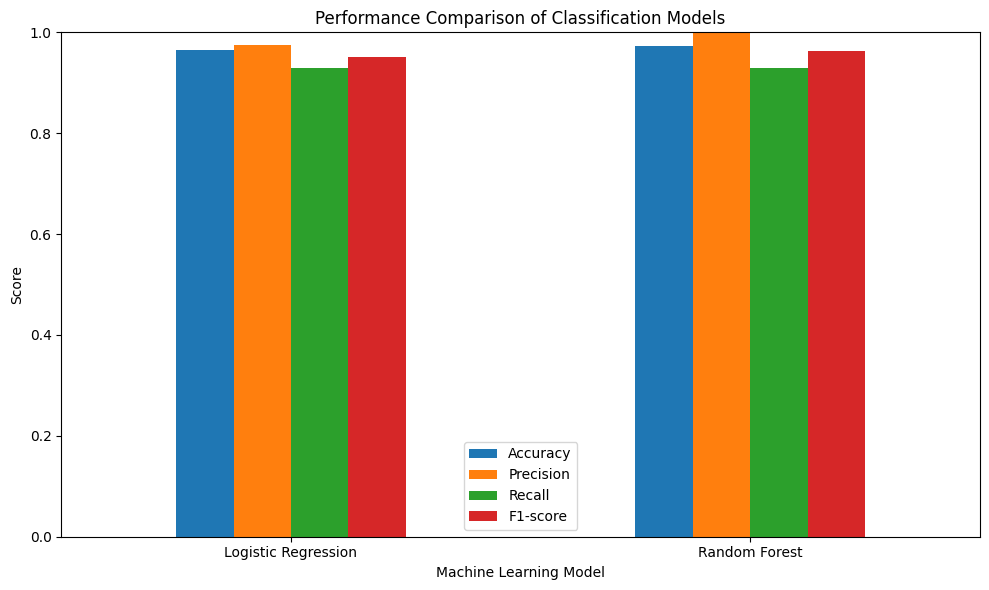

In [118]:
# Model performance comparison
results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-score']
].plot(
    kind='bar',
    figsize=(10, 6),
    ylim=(0, 1),
    rot=0
)

plt.title('Performance Comparison of Classification Models')
plt.ylabel('Score')
plt.xlabel('Machine Learning Model')
plt.tight_layout()
plt.show()

## Conclusion

The Breast Cancer Classification project successfully demonstrated the application of machine learning to classify tumors as benign or malignant using the Wisconsin Diagnostic dataset. The data was cleaned and analyzed, and Logistic Regression and Random Forest models were trained and evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

The performance comparison helped identify the better-performing model based on the evaluation results. Malignant-class recall was given particular importance because false-negative predictions can have serious consequences. Overall, this project provided practical experience with data preprocessing, visualization, model training, prediction, and evaluation. The model is intended for educational purposes and should not be used as a substitute for professional medical diagnosis.
